In [244]:
import autograd.numpy as np  # Import wrapped NumPy from autograd
from autograd import grad    # Import grad function to compute gradients
import matplotlib.pyplot as plt

n = 100
m = 50
A = np.random.uniform(-10, 2, (m,n))
#A = np.eye(n)
At = A.transpose()
K = np.random.uniform(-10, 2, (m,n)).transpose()

true_x = np.random.rand(n)
y = np.dot(A, true_x)

def f(x):
    return 0.5 * np.linalg.norm(np.dot(A,x)-y)**2

# Compute the gradient of f using autograd
grad_f_autodiff = grad(f)

def mm_grad_f(K, x):
    return np.dot(K, np.dot(A, x) - y)

def grad_f(x):
    return np.dot(At, np.dot(A, x) - y)

#lmo for the l1 ball, defined also for matrices
def lmo(gradient, rad):
    index_flat = np.argmax(np.abs(gradient))
    index_2d = np.unravel_index(index_flat, gradient.shape)
    output = np.zeros_like(gradient)
    output[index_2d] = -np.sign(gradient[index_2d])
    return output * rad

iterations = range(5000)

x = np.zeros(n)
objective_values = []
fw_gaps = []

for i in iterations:
    step_size = 1./(i+1)
    closeness = 1./(i+1)**.1
    Kclose = (1-closeness)*At + closeness*K
    gradient = mm_grad_f(Kclose, x)
    s = lmo(gradient, 10)
    real_s = lmo(grad_f(x), 10)
    # Compute the FW gap
    fw_gap = np.dot(grad_f(x), x - real_s)
    # Store the FW gap
    fw_gaps.append(fw_gap)
    x = x + step_size*(s-x)
    objective_values.append(f(x))

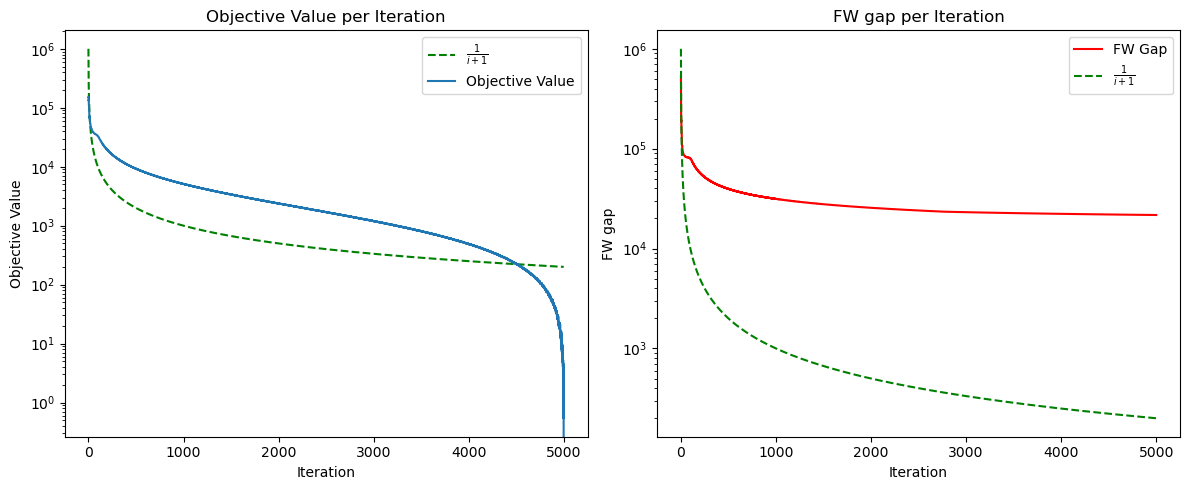

In [246]:
# Compute the theoretical convergence rate
theoretical_rate = [1e6/(i+1) for i in iterations]

# Create a figure with a 1x2 grid of subplots
plt.figure(figsize=(12, 5))

# Plotting the original objective values
plt.subplot(1, 2, 1)
plt.plot(iterations, theoretical_rate, linestyle='--', color='g', label=r'$\frac{1}{i+1}$')
plt.plot(iterations, objective_values-objective_values[-1], label='Objective Value')
plt.yscale('log')
plt.title('Objective Value per Iteration')
plt.xlabel('Iteration')
plt.ylabel('Objective Value')
plt.legend()

# Plotting the original FW gaps
plt.subplot(1, 2, 2)
plt.plot(iterations, fw_gaps, color='r', label='FW Gap')
plt.plot(iterations, theoretical_rate, linestyle='--', color='g', label=r'$\frac{1}{i+1}$')
plt.yscale('log')
plt.title('FW gap per Iteration')
plt.xlabel('Iteration')
plt.ylabel('FW gap')
plt.legend()

plt.tight_layout()
plt.show()